# 스쿨존 사고 예측 모델 전체 구조 정리

본 연구에서는 **두 개의 모델**을 사용한다.

1. **1차 모델 : 도로 구조 기반 위험 예측 모델**
2. **2차 모델 : 시설 + 인구 + 이미지 기반 사고 예측 모델**

두 모델의 역할이 다르다.

---

## 1. 1차 모델 (도로 구조 위험 모델)

목적
**도로 구조 자체가 사고 위험을 만드는지 분석**

즉,

> 구조적으로 위험한 스쿨존을 찾는 모델

---

사용 변수

| 변수 | 의미 |
|---|---|
| p_wide | 도로가 넓은지 여부 |
| p_barrier_yes | 보행자 펜스 존재 |
| road_width_relative | 상대적인 도로 폭 |
| sidewalk_ratio | 보도 비율 |
| parked_density | 불법주차 밀도 |

---

모델

**Logistic Regression**

예측 대상

**accident_label**
0 = 사고 없음
1 = 사고 발생


---

성능

| 지표 | 결과 |
|---|---|
| CV AUC | 0.71 |
| CV F1 | 0.63 |
| Spatial AUC | 0.71 |
| External AUC (성남) | 0.63 |

해석

- 모델이 **사고 위험을 중간 수준 정확도로 구분**
- 다른 지역에서도 **성능 유지**

---

정책 성능

| 지표 | 결과 |
|---|---|
| Top 20% Capture | 0.32 |
| Precision@20% | 0.75 |

의미

위험 상위 **20% 스쿨존**

→ 전체 사고의 **32% 포함**

---

## 2. 2차 모델 (시설 + 인구 + 이미지 기반 사고 예측 모델)

목적

**실제 사고 발생 가능성을 예측**

즉

> 정책적으로 **사고 발생 가능성이 높은 스쿨존**을 찾는 모델

---

사용 변수

1) 이미지 기반

| 변수 | 의미 |
|---|---|
| structure_risk | 도로 구조 위험 점수 (Custom Vision 기반) |

---

2) 안전시설

| 변수 |
|---|
도로안전표지  
도로적색표면  
무단횡단방지펜스  
무인교통단속카메라  
보호구역표지판  
생활안전CCTV  
신호등  
옐로카펫  
횡단보도  

---

3) 인구 변수

| 변수 |
|---|
어린이 총인구  
어린이 비율 |

---

모델

**Logistic Regression**

---

성능

| 지표 | 결과 |
|---|---|
| Mean CV AUC | 0.92 |
| Mean F1 | 0.54 |

해석

- 사고 지역과 비사고 지역을 **매우 잘 구분**
- 사고 데이터가 적어서 **F1은 중간 수준**

---

정책 성능

| 지표 | 결과 |
|---|---|
| Top 20% Capture | 1.0 |
| Precision@20% | 0.31 |

의미

위험 상위 **20% 스쿨존**

→ **모든 사고 지역 포함**

즉

> 사고 위험 지역을 **정책적으로 매우 잘 선별**

---

## 3. 모델 비교

| 항목 | 1차 모델 | 2차 모델 |
|---|---|---|
| 목적 | 구조 위험 분석 | 사고 발생 예측 |
| 변수 | 도로 구조 | 시설 + 인구 + 이미지 |
| CV AUC | 0.71 | 0.92 |
| Top20 Capture | 0.32 | 1.00 |

---

## 4. 전체 모델 구조

도로 이미지 \
↓ \
구조 위험 추출 (Custom Vision) \
↓ \
Structure Risk 생성 \
↓ \
1차 모델 \
도로 구조 위험 분석 \
↓ \
2차 모델 \
시설 + 인구 + 구조 위험 → 사고 발생 확률 예측 
↓ \
정책 출력 \
→ 안전 점수 및 등급 (A,B,C,D)

---

## 5. 핵심 결론

본 연구는 **두 단계 구조**를 가진다.

1차 모델
도로 구조만으로 **기본 위험 패턴 분석**

2차 모델
시설 + 인구 + 이미지 정보를 결합하여  
**실제 사고 발생 가능성을 예측**

결과적으로

> 2차 모델은 위험 상위 20% 지역에서  
> **전체 사고를 모두 포함하는 성능을 보였다.**

---

# 1번째 모델 = custom vision 결과로 Structure Risk 모델링
도로 환경이 얼마나 위험한지 나타내는 구조 점수를 계산하는 것이며 \
우리 프로젝트의 첫번째 모델이다.

#### 모델링을 위한 데이터 준비
##### Custom Vision 학습 데이터 통합

In [23]:
import pandas as pd

# 이미지 classification_ 도로가 좁은지(1차선) - 넓은지 (2차선~) , 펜스 등 장애물이 있는지 - 확률 데이터
class_df = pd.read_csv(r"C:\Users\EL36\Desktop\1차프로젝트_CCTV\1stProject_MSAI09\CustomVision\0_classification_features.csv")
class_df["시설물명"] = class_df["image"].str.replace("_북쪽.png", "", regex=False)
class_df["시설물명"] = class_df["시설물명"].str.replace(r"_\d+", "", regex=True)

# 이미지 object detection_ 주정차차량, 보행자 인도 존재 여부, 도로 넓이 등 객체의 수와 위치 정보 데이터
obj_df = pd.read_csv(r"C:\Users\EL36\Desktop\1차프로젝트_CCTV\1stProject_MSAI09\CustomVision\0_object_detection_features.csv")

obj_df["시설물명"] = obj_df["image"].str.replace("_북쪽.png", "", regex=False)
obj_df["시설물명"] = obj_df["시설물명"].str.replace(r"_\d+", "", regex=True)

# 커스텀비전으로 만든 img feature끼리 먼저 병합
image_df = class_df.merge(obj_df, on=["image", "시설물명"], how="inner")

##### 시설물의 정확한 구분을 위해 사고 여부, 시군구 지역 정보를 추가한다.

In [24]:
# 시설물명으로 merge 하기 위해 image_df의 시설물명에서 '_'와 '.png' 제거
image_df['시설물명'] = image_df['시설물명'].str.replace('_', ' ').str.replace('.png', '')

In [25]:
# 스쿨존 사고다발지 데이터 불러오기
count_df = pd.read_csv(r'C:\Users\EL36\Desktop\1차프로젝트_CCTV\1stProject_MSAI09\Raw-Data\스쿨존 사고데이터\전국교통사고다발지역표준데이터.csv', encoding='cp949')
# 어린이 사고만 필터링
count_df = count_df[count_df['사고유형구분'].str.contains('어린이')] 
# merge를 위해 컬럼명 변경
count_df = count_df.rename(columns={'사고지역위치명': '시설물명','사고건수':'발생건수','부상신고자수':'부상자수','사고다발지역시도시군구':'시군구'})
# image_df에 count_df merge 하여 사고 건수 추가
image_df = image_df.merge(count_df[['시설물명', '시군구', '발생건수', '사상자수', '사망자수', '중상자수', '경상자수', '부상자수', '위도', '경도']], on='시설물명', how='left')
image_df[image_df.isna().any(axis=1)].head(3)

,image,p_wide,p_narrow,p_barrier_yes,p_barrier_no,시설물명,road_width_relative,sidewalk_ratio,parked_density,시군구,발생건수,사상자수,사망자수,중상자수,경상자수,부상자수,위도,경도
0,AMI몬테소리손바닥어린이집_북쪽.png,0.660075,0.344503,0.382240,0.614802,AMI몬테소리손바닥어린이집,0.400759,0.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AP어린이집_북쪽.png,0.940672,0.060079,0.822805,0.178012,AP어린이집,0.428197,0.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,EPS어린이집_북쪽.png,0.004515,0.995615,0.005522,0.994376,EPS어린이집,0.000000,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# 사고 다발지가 아닌 경우 NaN으로 표시되었다. 
# 경기도 스쿨존 데이터로 NaN 값 채우기위해 불러오기
gg_df = pd.read_csv(r'C:\Users\EL36\Desktop\1차프로젝트_CCTV\1stProject_MSAI09\Raw-Data\0. 스쿨존목록\0_어린이보호구역현황_경기도.csv')
gg_df = gg_df.rename(columns={'대상시설명': '시설물명', '소재지도로명주소': '시군구', '소재지지번주소': '시군구2'})

In [27]:
# 경기도 스쿨존 데이터로 위도, 경도 , 시도시군구명 nan 값 채우기
image_df = image_df.merge(gg_df[['시설물명','시군구','시군구2','위도','경도']],on='시설물명',how='left',suffixes=('', '_new'))
image_df['위도'] = image_df['위도'].fillna(image_df['위도_new'])
image_df['경도'] = image_df['경도'].fillna(image_df['경도_new'])
image_df['시군구'] = image_df['시군구'].fillna(image_df['시군구_new'])
image_df['시군구'] = image_df['시군구'].fillna(image_df['시군구2'])

image_df = image_df.drop(columns=['위도_new','경도_new','시군구_new','시군구2'])

In [28]:
# 시군구 정보가 여전히 없는 행 확인 후, 이를 채워주려 한다.
# 원본 데이터 훼손 방지를 위해 별도의 데이터프레임으로 저장
missing_df = image_df[image_df['시군구'].isna()].copy()

In [29]:
# 시군구 정보가 없는 행들에 대해, 이미지 파일명에서 시군구 정보를 추출하여 채워넣기 위한 매핑 딕셔너리 생성
# 일괄적으로 시군구 정보를 추출하기 어려워서, 수동으로 매핑을 작성하여 시군구 정보를 채워넣는다.
mapping = {
'경기도_남양주시_진접읍(주공2단지아파트_107동_부근)_01.png':'경기도 남양주시 진접읍(주공2단지아파트 107동 부근)',
'경기도_오산시_누읍동(누읍휴먼시아_106동_부근)_01.png':'경기도 오산시 누읍동(누읍휴먼시아 106동 부근)',
'경기도_오산시_수청동(오산대역_1호선_부근)_01.png':'경기도 오산시 수청동(오산대역 1호선 부근)',
'경기도_평택시_비전동(시대코아아파트_201동_부근)_01.png':'경기도 평택시 비전동(시대코아아파트 201동 부근)',
'경기도_평택시_용이동(비전아이파크아파트_101동앞사거리_부근)_01.png':'경기도 평택시 용이동(비전아이파크아파트 101동앞사거리 부근)',
'경기도_화성시_병점동(늘벗미션힐1차아파트_113동앞_부근)_01.png':'경기도 화성시 병점동(늘벗미션힐1차아파트 113동앞 부근)',
'경기도_화성시_오산동(동탄역중흥S_1708동_부근)_01.png':'경기도 화성시 오산동(동탄역중흥S 1708동 부근)',
'경상남도_거제시_고현동(양정고려2차아파트_204동_부근)_01.png':'경상남도 거제시 고현동(양정고려2차아파트 204동 부근)',
'광주광역시_광산구_장덕동(신완마을휴먼시아7단지_711동앞_부근)_01.png':'광주광역시 광산구 장덕동(신완마을휴먼시아7단지 711동앞 부근)',
'대전광역시_서구_내동(벽산블루밍맑은아침아파트_112동_부근)_01.png':'대전광역시 서구 내동(벽산블루밍맑은아침아파트 112동 부근)',
'서울특별시_강서구_화곡동(화곡역_화곡로_진입_2_부근)_01.png':'서울특별시 강서구 화곡동(화곡역_화곡로_진입_2 부근)',
'서울특별시_마포구_용강동(신석초등교앞_대흥로_진입_부근)_01.png':'서울특별시 마포구 용강동(신석초등교앞_대흥로_진입 부근)',
'서울특별시_서초구_우면동(서초네이처힐_3단지_314동_부근)_01.png':'서울특별시 서초구 우면동(서초네이처힐 3단지 314동 부근)',
'서울특별시_중구_신당동(약수역_다산로_진출_2_부근)_01.png':'서울특별시 중구 신당동(약수역_다산로_진출_2 부근)',
'울산광역시_남구_신정동(신정현대홈타운_3단지_부근)_01.png':'울산광역시 남구 신정동(신정현대홈타운 3단지 부근)',
'충청남도_아산시_배방읍(연화마을휴먼시아7단지_703동앞_부근)_01.png':'충청남도 아산시 배방읍(연화마을휴먼시아7단지 703동앞 부근)',
'충청남도_천안시_동남구_신방동(성지새말_2단지아파트_부근)_01.png':'충청남도 천안시 동남구 신방동(성지새말 2단지아파트 부근)'
}
missing_df['시설물명'] = missing_df['image'].map(mapping)

In [30]:
# 따로 뗴어놓은 missing_df에 시군구 정보가 있는 count_df를 merge하여 시군구 정보 채우기
missing_df = missing_df.merge(count_df[['시설물명', '시군구', '발생건수', '사상자수', '사망자수', '중상자수', '경상자수', '부상자수', '위도', '경도']], on='시설물명', how='left', suffixes=('', '_new'))
missing_df['시군구'] = missing_df['시군구_new']
missing_df['발생건수'] = missing_df['발생건수_new']
missing_df['사상자수'] = missing_df['사상자수_new']
missing_df['사망자수'] = missing_df['사망자수_new']
missing_df['중상자수'] = missing_df['중상자수_new']
missing_df['경상자수'] = missing_df['경상자수_new']
missing_df['부상자수'] = missing_df['부상자수_new']
missing_df['위도'] = missing_df['위도_new']
missing_df['경도'] = missing_df['경도_new']

missing_df = missing_df.drop(columns=['시군구_new', '발생건수_new', '사상자수_new', '사망자수_new', '중상자수_new', '경상자수_new', '부상자수_new', '위도_new', '경도_new'])

In [31]:
# 따로 떼어놨던 데이터프레임을 원본 데이터프레임에 업데이트
cols = ['시군구','발생건수','사상자수','사망자수','중상자수','경상자수','부상자수','위도','경도']

image_df = image_df.set_index('image')
missing_df = missing_df.set_index('image')

image_df.update(missing_df[cols])

image_df = image_df.reset_index()

In [32]:
# image df의 사고 건수 fillna 인 경우  0으로 채우기
cols = ['발생건수','사상자수','사망자수','중상자수','경상자수','부상자수']
image_df[cols] = image_df[cols].fillna(0).astype(int)

In [33]:
# 결측치 없는 것으로 확인
image_df[image_df.isnull().any(axis=1)]

,image,p_wide,p_narrow,p_barrier_yes,p_barrier_no,시설물명,road_width_relative,sidewalk_ratio,parked_density,시군구,발생건수,사상자수,사망자수,중상자수,경상자수,부상자수,위도,경도


##### 지역 정보 추가

In [34]:
# 시군구 정보를 ㅇㅇ도 ㅇㅇ시 로 통일
image_df['시군구'] = (image_df['시군구'].str.replace(r'\d+', '', regex=True).str.split().str[:2].str.join(' '))

In [35]:
# 생성 확인 및 오류 난 부분 확인
pd.set_option('display.max_rows', None)
image_df.groupby('시군구').size()

시군구
강원특별자치도 강릉시       6
강원특별자치도 동해시       8
강원특별자치도 삼척시       1
강원특별자치도 속초시       2
강원특별자치도 양양군       1
강원특별자치도 원주시      10
강원특별자치도 춘천시       7
강원특별자치도 횡성군       2
경기도 가평군          21
경기도 고양시         143
경기도 과천시           9
경기도 광명시          59
경기도 광주시          80
경기도 구리시          20
경기도 군포시          54
경기도 김포시         117
경기도 남양주시        144
경기도 동두천시         32
경기도 부천시         105
경기도 성남시         145
경기도 수원시         211
경기도 수정구           1
경기도 시흥시         144
경기도 안산시         249
경기도 안성시          91
경기도 안양시          58
경기도 양주시          98
경기도 양평군          22
경기도 여주군           1
경기도 여주시          24
경기도 연천군          14
경기도 오산시          80
경기도 용인시         210
경기도 의왕시          18
경기도 의정부시         80
경기도 이천시          65
경기도 파주시          93
경기도 평택시         138
경기도 포천시          83
경기도 하남시          38
경기도 화성시         198
경상남도 거제시         25
경상남도 거창군          5
경상남도 고성군          1
경상남도 김해시         19
경상남도 밀양시          2
경상남도 사천시          4
경상남도 양산시          4
경상남도 진주시          6
경상남도 창녕군        

In [36]:
# 오류난 부분 수정
fix_map = {
    '경기도 수정구': '경기도 성남시',
    '경기도 여주군': '경기도 여주시',
    '충청북도 청원군': '충청북도 청주시'
}

image_df['시군구'] = image_df['시군구'].replace(fix_map)
image_df['시군구'].value_counts().loc[list(fix_map.values())]

시군구
경기도 성남시     146
경기도 여주시      25
충청북도 청주시     65
Name: count, dtype: int64

##### 사고 여부 라벨 생성

In [37]:
# '사고 여부' 라벨 생성 
image_df["accident_label"] = (image_df["발생건수"] >= 1).astype(int)

##### 파일로 저장

In [38]:
image_df.to_csv(r"C:\Users\EL36\Desktop\1차프로젝트_CCTV\1stProject_MSAI09\ML_jw\1_DatasetFor1stData.csv", index=False)

## 신규 데이터셋으로 Structure Risk 모델 학습 및 구조위험점수 산출
로지스틱 회귀 사용 \
Stratified K fold, Group K fold 로 교차 검증 \
모델 평가


=== Stratified CV ===
AUC per fold: [0.7095896920036194, 0.7265641191546148, 0.7255531348097075, 0.6999095466213894, 0.7016169066023686]
Mean CV AUC: 0.71264667983834
Mean CV F1: 0.6282164447493747

=== GroupKFold (Spatial Validation) ===
Group AUC per fold: [0.7292779126213593, 0.6732928005880822, 0.7108247422680414, 0.7353928118648502, 0.6957569038500303]
Mean Group AUC: 0.7089090342384726

=== Policy Evaluation ===
Top-20% Capture: 0.3213939980638916
Precision@20%: 0.745230078563412

=== External Validation (Seongnam) ===
Seongnam AUC: 0.6330995792426367


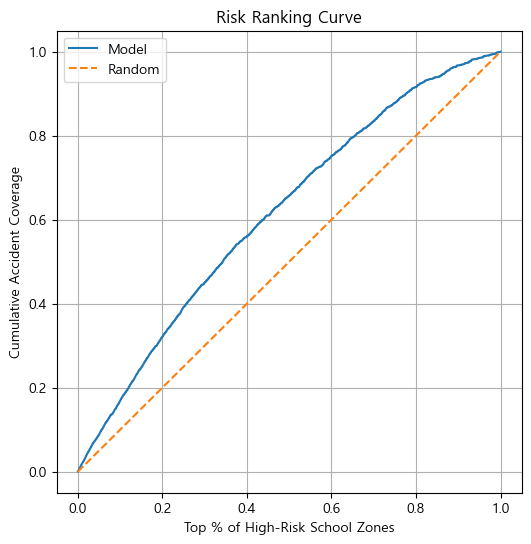

In [39]:
# ============================================================
# 1. 라이브러리 및 데이터 로드
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score

# 데이터 로드
df = pd.read_csv(
r"C:\Users\EL36\Desktop\1차프로젝트_CCTV\1stProject_MSAI09\ML_jw\1_DatasetFor1stData.csv"
)

# ============================================================
# 2. Feature 및 Target 정의
# ============================================================

features_1st_lr = [
    "p_wide",
    "p_barrier_yes",
    "road_width_relative",
    "sidewalk_ratio",
    "parked_density"
]

X = df[features_1st_lr]
y = df["accident_label"]

# ============================================================
# 3. 모델 정의 (표준화 + 로지스틱 회귀)
# ============================================================

model_1st_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

# ============================================================
# 4. Stratified Cross Validation
# 목적: 모델의 기본 분류 성능 평가
# ============================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = []
f1_scores = []

for train_idx, test_idx in skf.split(X, y):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model_1st_lr.fit(X_train, y_train)

    probs = model_1st_lr.predict_proba(X_test)[:,1]
    preds = (probs > 0.5).astype(int)

    auc_scores.append(roc_auc_score(y_test, probs))
    f1_scores.append(f1_score(y_test, preds))

print("\n=== Stratified CV ===")
print("AUC per fold:", auc_scores)
print("Mean CV AUC:", np.mean(auc_scores))
print("Mean CV F1:", np.mean(f1_scores))


# ============================================================
# 5. GroupKFold (공간 검증)
# 목적: 지역 간 일반화 성능 평가
# ============================================================

groups = df["시군구"]

gkf = GroupKFold(n_splits=5)

group_auc = []

for train_idx, test_idx in gkf.split(X, y, groups):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model_1st_lr.fit(X_train, y_train)

    probs = model_1st_lr.predict_proba(X_test)[:,1]

    group_auc.append(roc_auc_score(y_test, probs))

print("\n=== GroupKFold (Spatial Validation) ===")
print("Group AUC per fold:", group_auc)
print("Mean Group AUC:", np.mean(group_auc))


# ============================================================
# 6. 정책 지표 계산
# Top-20% Capture + Precision@20%
# ============================================================

df_eval = df.copy()

# 전체 데이터로 모델 재학습
model_1st_lr.fit(X, y)

# 예측 확률 생성
df_eval["pred"] = model_1st_lr.predict_proba(X)[:,1]

# 위험도 기준 정렬
df_eval = df_eval.sort_values("pred", ascending=False)

# 상위 20% 선택
k = int(len(df_eval) * 0.2)
top_k = df_eval.head(k)

# 사고 설명률 (Top-20% Capture)
capture_rate = (
    top_k["accident_label"].sum() /
    df_eval["accident_label"].sum()
)

# Precision@20%
precision_k = top_k["accident_label"].mean()

print("\n=== Policy Evaluation ===")
print("Top-20% Capture:", capture_rate)
print("Precision@20%:", precision_k)


# ============================================================
# 7. 성남시 외부 검증
# 목적: 행정구 단위 독립 검증
# ============================================================

train_df = df[~df["시군구"].str.contains("성남시", na=False)]
test_df  = df[df["시군구"].str.contains("성남시", na=False)]

X_train = train_df[features_1st_lr]
y_train = train_df["accident_label"]

X_test = test_df[features_1st_lr]
y_test = test_df["accident_label"]

# 성남 제외 데이터로 모델 학습
model_1st_lr.fit(X_train, y_train)

# 성남 예측
probs = model_1st_lr.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, probs)

print("\n=== External Validation (Seongnam) ===")
print("Seongnam AUC:", auc)


# ============================================================
# 8. Risk Ranking Curve (누적 사고 설명률 그래프)
# 목적: 정책 설명력 시각화
# ============================================================

df_curve = df_eval.copy()

# 누적 사고 수 계산
df_curve["cum_accident"] = df_curve["accident_label"].cumsum()

# 전체 사고 수
total_accidents = df_curve["accident_label"].sum()

# 누적 사고 비율
df_curve["cum_accident_rate"] = df_curve["cum_accident"] / total_accidents

# 누적 지역 비율
df_curve["cum_area_rate"] = np.arange(1, len(df_curve)+1) / len(df_curve)

# 그래프
plt.figure(figsize=(6,6))

plt.plot(
    df_curve["cum_area_rate"],
    df_curve["cum_accident_rate"],
    label="Model"
)

# 랜덤 기준선
plt.plot([0,1],[0,1],"--",label="Random")

plt.xlabel("Top % of High-Risk School Zones")
plt.ylabel("Cumulative Accident Coverage")
plt.title("Risk Ranking Curve")

plt.legend()
plt.grid(True)

plt.show()

#### 스쿨존 사고 위험 예측 모델 결과 해석 (1차 모델)

1. 모델 분류 성능

| 지표 | 값 | 의미 |
|---|---|---|
| Mean CV AUC | 0.71 | 사고 지역과 비사고 지역을 **중간 수준으로 구분 가능** |
| Mean CV F1 | 0.63 | 사고 지역을 찾는 성능 **보통 수준** |

해석

- AUC **0.71**  
→ 모델이 **완전히 무작위(Random)** 보다 **확실히 더 잘 구분한다**.

- F1 **0.63**  
→ 사고 지역 탐지 성능이 **실용적으로 사용할 수 있는 수준**이다.

---

2. 공간 일반화 성능 (GroupKFold)

| 지표 | 값 |
|---|---|
| Mean Group AUC | 0.71 |

의미

- 지역 단위로 데이터를 분리했을 때도  
  **성능이 거의 동일하게 유지된다.**

즉

> 특정 지역에만 맞춰진 모델이 아니라  
> **다른 지역에도 적용 가능한 모델**이다.

---

3. 정책 활용 성능

| 지표 | 값 | 의미 |
|---|---|---|
| Top-20% Capture | 0.32 | 위험 상위 20% 지역이 **전체 사고의 32% 설명** |
| Precision@20% | 0.75 | 상위 위험 지역 중 **75%가 실제 사고 지역** |

해석

- 모델이 선택한 **위험 상위 20% 지역 중**

**약 75%가 실제 사고 지역**

즉

> 모델이 **위험 지역을 비교적 정확하게 선별한다.**

---

4. 외부 검증 (성남시)

| 지표 | 값 |
|---|---|
| Seongnam AUC | 0.63 |

의미

- 학습에 사용하지 않은 **새로운 도시(성남)**에서도  
  모델이 **기본적인 예측 능력을 유지한다.**

다만

- 성능이 **0.71 → 0.63**으로 감소

→ 지역 환경 차이 영향 존재

---

5. Risk Ranking Curve 해석

그래프 의미

- **가로축:** 위험도가 높은 스쿨존 상위 비율  
- **세로축:** 누적 사고 설명률

그래프 특징

- 파란선이 **Random 기준선보다 위에 있음**

즉

> 모델이 **무작위 선택보다 더 많은 사고를 상위 위험 지역에 집중시킨다.**

예시 해석

- 상위 **20% 지역 → 약 32% 사고 설명**

---

6. 종합 평가

이 모델은

- 사고 위험 지역을 **중간 수준 정확도로 구분(AUC ≈ 0.71)**
- 지역이 바뀌어도 **비슷한 성능 유지**
- 위험 상위 지역을 **정책적으로 선별 가능**

하지만

- 사고의 약 **1/3 정도만 상위 위험지역에 집중**

따라서

> 이 모델은 **기초 위험 선별 모델**로 사용 가능하며  
> 이후 **시설 변수 및 이미지 위험 변수 추가 모델이 필요하다.**

#### 변수 검증

In [40]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 사용할 feature 리스트 지정
features = [
    "p_wide",
    "p_barrier_yes",
    "road_width_relative",
    "sidewalk_ratio",
    "parked_density"
]

# X 구성
X = df[features].copy()

# 결측 제거 (VIF는 결측 허용 안 함)
X = X.dropna()

# 상수항 추가
X_const = add_constant(X)

# VIF 계산
vif_df = pd.DataFrame()
vif_df["feature"] = X_const.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]

print(vif_df)

               feature       VIF
0                const  8.185667
1               p_wide  3.014089
2        p_barrier_yes  3.326552
3  road_width_relative  1.249873
4       sidewalk_ratio  1.602189
5       parked_density  1.174084


공선성(VIF) 진단 결과 해석

1. VIF 판단 기준

| VIF 값 | 해석 |
|------|------|
| 1 ~ 5 | 공선성 문제 없음 |
| 5 ~ 10 | 다소 높은 수준 (주의 필요) |
| 10 이상 | 공선성 문제 심각 |

---

2. 결과 해석

- 모든 설명 변수의 **VIF 값이 5 이하**이다.
- 이는 변수들 사이에 **강한 공선성이 존재하지 않음을 의미한다.**
- 각 변수는 **서로 다른 정보를 제공하는 변수로 볼 수 있다.**

또한

- `const`는 회귀 모델 계산을 위한 **상수항(intercept)** 이므로  
  **공선성 판단 대상에서 제외한다.**

---

3. 결론

- 분석에 사용된 변수들 사이에는 **공선성 문제가 발견되지 않았다.**
- 따라서 **모든 변수를 모델에 함께 사용해도 통계적으로 문제가 없는 수준이다.**

# 2번째 모델 = 시설 데이터 포함시켜 최종 안전점수 도출
1번 모델에서 사용한 데이터는 '사고다발지' + '경기도 스쿨존'을 합친 것이라, 사고 지역의 비율이 높다. \
2번 모델에서 사용할 데이터는 '성남시 스쿨존'을 기반으로 하여, 사고 지역 비율을 현실화 했다. \
'스쿨존 시설물 개수'에 '사고 여부' 및 'structure risk'를 합쳐, \
환경구조적 위험에 대해 정책적으로 어떻게 대비할 수 있을지 예측하는 모델을 수립한다.

##### 데이터 준비 - 성남시 스쿨존 시설 데이터에 Structure Risk 점수를 합친 데이터 프레임 생성

In [41]:
# 필요 데이터 불러오기
seongnam_df = pd.read_csv(r"C:\Users\EL36\Desktop\1차프로젝트_CCTV\1stProject_MSAI09\Preprocessing\5_seongnam_final_dataset.csv")
df = pd.read_csv(r"C:\Users\EL36\Desktop\1차프로젝트_CCTV\1stProject_MSAI09\CustomVision\accidentlevel_addData.csv")

# 성남시 스쿨존 데이터와 커스텀비전으로 만든 이미지 feature 데이터 병합
facility_df = seongnam_df.merge(df[['시설물명','p_wide','p_narrow','p_barrier_yes','p_barrier_no','road_width_relative','sidewalk_ratio','parked_density']], on="시설물명", how="inner")
facility_df["accident_label"] = (facility_df["발생건수"] >= 1).astype(int)
facility_df.drop_duplicates("시설물명")

# 병합 데이터에서 structure risk 계산
features = ["p_wide","p_barrier_yes","road_width_relative","sidewalk_ratio","parked_density"]
facility_df["structure_risk"] = model_1st_lr.predict_proba(facility_df[features])[:, 1]

facility_df.to_csv(r"C:\Users\EL36\Desktop\1차프로젝트_CCTV\1stProject_MSAI09\ML_jw\2_DatasetFor2ndData.csv.csv", index=False)

### 시설, 인구 점수 계산하고 사고 예측하는 2번째 모델링

#### 사고 예측 모델 (로지스틱 회귀)

In [42]:
# ============================================================
# 사고 예측 모델 구축 및 평가
# ============================================================

# 필요한 라이브러리 불러오기
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd


# ============================================================
# 1. 모델링을 위한 Feature와 Target 정의
# ============================================================

facility_df = pd.read_csv(r"C:\Users\EL36\Desktop\1차프로젝트_CCTV\1stProject_MSAI09\ML_jw\2_DatasetFor2ndData.csv.csv")

# 모델에 사용할 입력 변수 (설명 변수)
features_2nd_lr = [
    "structure_risk",      # 이미지 기반 구조 위험 점수
    "도로안전표지",
    "도로적색표면",
    "무단횡단방지펜스",
    "무인교통단속카메라",
    "보호구역표지판",
    "생활안전CCTV",
    "신호등",
    "옐로카펫",
    "횡단보도",
    "어린이 총인구",        # 절대 어린이 수 (노출 변수)
    "어린이 비율(%)"        # 어린이 인구 구조 변수
]

# 입력 데이터(X)와 타겟(y) 설정
X = facility_df[features_2nd_lr]
y = facility_df["accident_label"]   # 사고 발생 여부 (0: 없음, 1: 있음)


# ============================================================
# 2. 모델 정의
# ============================================================

# StandardScaler : 변수 스케일 표준화
# LogisticRegression : 사고 발생 확률 예측 모델
model_2nd_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",   # 클래스 불균형 보정
        solver="lbfgs"
    ))
])


# ============================================================
# 3. Stratified K-Fold Cross Validation
# ============================================================

# StratifiedKFold는 클래스 비율을 유지하면서 데이터를 나누는 방식
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# AUC 기반 교차검증 성능 평가
cv_auc = cross_val_score(
    model_2nd_lr,
    X,
    y,
    cv=skf,
    scoring="roc_auc"
)

# F1 Score 기반 교차검증 성능 평가
cv_f1 = cross_val_score(
    model_2nd_lr,
    X,
    y,
    cv=skf,
    scoring="f1"
)


# ============================================================
# 4. 전체 데이터로 모델 학습
# ============================================================

# 최종 모델 학습
model_2nd_lr.fit(X, y)

# 예측 결과 (0 또는 1)
y_pred = model_2nd_lr.predict(X)

# 사고 발생 확률 (0~1)
y_prob = model_2nd_lr.predict_proba(X)[:,1]


# ============================================================
# 5. 모델 성능 출력
# ============================================================

print("CV AUC:", cv_auc)
print("Mean CV AUC:", cv_auc.mean())
print("Mean F1:", cv_f1.mean())

# Classification Report 출력
# Precision / Recall / F1 Score 확인
print(classification_report(
    y,
    y_pred,
    target_names=["없음(0건)", "있음(1건~)"]
))


# ============================================================
# 6. 정책 활용 지표 계산
# Top-20% Capture + Precision@20%
# ============================================================

# 각 스쿨존의 사고 발생 확률 저장
facility_df["risk_prob"] = y_prob

# 위험도 상위 20% 기준값 계산
threshold = np.percentile(y_prob, 80)

# 위험도 상위 20% 지역 추출
top20 = facility_df[facility_df["risk_prob"] >= threshold]

# Top-20% Capture
# 상위 20% 위험지역이 전체 사고 중 얼마나 설명하는지
capture_rate = (
    top20["accident_label"].sum() /
    facility_df["accident_label"].sum()
)

# Precision@20%
# 상위 20% 위험지역 중 실제 사고 발생 비율
precision20 = top20["accident_label"].mean()

print("Top20 Capture:", capture_rate)
print("Precision@20%:", precision20)


# ============================================================
# 7. Confusion Matrix
# ============================================================

# 실제값 vs 예측값 비교
cm = confusion_matrix(y, y_pred)

print("Confusion Matrix:", cm)


# ============================================================
# 8. Feature Importance (로지스틱 회귀 계수)
# ============================================================

# 로지스틱 회귀 계수 추출
coef = model_2nd_lr.named_steps["logit"].coef_[0]

# 변수 중요도 정리
importance = pd.DataFrame({
    "feature": features_2nd_lr,
    "coef": coef
}).sort_values("coef", ascending=False)

print("Feature Importance (Coefficient):")
print(importance)

CV AUC: [1.         1.         0.625      0.95833333 1.        ]
Mean CV AUC: 0.9166666666666666
Mean F1: 0.54
              precision    recall  f1-score   support

      없음(0건)       1.00      0.90      0.95       121
     있음(1건~)       0.40      1.00      0.57         8

    accuracy                           0.91       129
   macro avg       0.70      0.95      0.76       129
weighted avg       0.96      0.91      0.92       129

Top20 Capture: 1.0
Precision@20%: 0.3076923076923077
Confusion Matrix: [[109  12]
 [  0   8]]
Feature Importance (Coefficient):
           feature      coef
5          보호구역표지판  2.360302
6         생활안전CCTV  1.455824
4        무인교통단속카메라  0.755163
10         어린이 총인구  0.457520
3         무단횡단방지펜스  0.049833
1           도로안전표지 -0.043470
7              신호등 -0.224745
0   structure_risk -0.333572
11       어린이 비율(%) -0.368354
8             옐로카펫 -0.942478
9             횡단보도 -1.115882
2           도로적색표면 -1.140637


스쿨존 사고 예측 모델 결과 해석

1. 모델 성능 (교차검증)

| 지표 | 값 | 의미 |
|---|---|---|
| Mean CV AUC | 0.92 | 사고 발생 지역과 비발생 지역을 **잘 구분하는 모델** |
| Mean F1 | 0.54 | 사고 지역을 찾는 성능은 **중간 수준** |

**해석**

- AUC가 **0.92**이므로 모델의 **전체 구분 능력은 높은 편**이다.
- 하지만 사고 데이터가 **매우 적기 때문에(F1=0.54)** 사고 지역을 정확히 찾는 성능은 완벽하지 않다.

---

2. 분류 성능 (Classification Report)

| 실제 | Precision | Recall | 의미 |
|---|---|---|---|
| 사고 없음 | 1.00 | 0.90 | 대부분 정확히 예측 |
| 사고 있음 | 0.40 | 1.00 | 사고 지역은 모두 찾았지만 일부 과대 예측 존재 |

**해석**

- **Recall = 1.00**

→ 실제 사고 지역 **8개를 모두 찾았다**

- **Precision = 0.40**

→ 사고라고 예측한 지역 중 **일부는 실제 사고가 없었다**

즉,

> 사고 위험 지역을 **놓치지 않는 모델이지만**,  
> 일부 지역을 **과하게 위험하다고 판단하는 경향**이 있다.

---

3. Confusion Matrix (예측 결과)

|  | 예측: 사고 없음 | 예측: 사고 있음 |
|---|---|---|
| 실제 사고 없음 | 109 | 12 |
| 실제 사고 있음 | 0 | 8 |

**해석**

- 사고 지역 **8곳 → 모두 맞춤**
- 사고가 없는 지역 **12곳 → 사고라고 잘못 예측**

---

4. 정책 활용 성능

| 지표 | 값 | 의미 |
|---|---|---|
| Top 20% Capture | 1.00 | 전체 사고의 **100%가 상위 위험지역에 포함** |
| Precision@20% | 0.31 | 상위 위험지역 중 **31%가 실제 사고 지역** |

**해석**

모델이 **위험도 상위 20% 지역만 관리해도**

- **모든 사고 지역을 포함할 수 있다.**

즉,

> 예산이 제한된 상황에서  
> **위험 상위 지역부터 집중 관리하는 정책 도구로 활용 가능하다.**

---

5. 주요 영향 변수 (Feature Importance)

사고 위험 증가와 관련된 변수

| 변수 | 의미 |
|---|---|
| 보호구역표지판 | 사고 위험 높은 지역에 많이 설치된 경향 |
| 생활안전CCTV | 사고 위험 높은 지역에 설치된 경우 많음 |
| 무인교통단속카메라 | 위험 지역에 설치된 경향 |
| 어린이 총인구 | 어린이 수가 많을수록 사고 노출 증가 |

※ 안전시설은 **사고를 발생시키는 것이 아니라**  
이미 **위험한 지역에 설치된 결과일 가능성**이 높다.

---

사고 위험 감소와 관련된 변수

| 변수 | 의미 |
|---|---|
| 도로적색표면 | 사고 감소와 관련 |
| 횡단보도 | 보행 안전 구조 |
| 옐로카펫 | 어린이 보행 안전 시설 |

---

6. 전체 결론

이 모델은

- **사고 발생 지역을 높은 정확도로 구분할 수 있으며 (AUC 0.92)**
- **사고 지역을 놓치지 않는 특성을 가진 모델이다.**

또한

> 위험도 **상위 20% 지역만 관리해도  
> 전체 사고 지역을 모두 포함할 수 있다.**

따라서 이 모델은

**스쿨존 사고 예방을 위한 정책 우선순위 선정 도구로 활용 가능하다.**

##### 로지스틱 회귀 기반 변수 중요도 추가 분석


=== Logistic Coefficient Importance ===
           feature      coef  abs_coef
5          보호구역표지판  2.360302  2.360302
6         생활안전CCTV  1.455824  1.455824
2           도로적색표면 -1.140637  1.140637
9             횡단보도 -1.115882  1.115882
8             옐로카펫 -0.942478  0.942478
4        무인교통단속카메라  0.755163  0.755163
10         어린이 총인구  0.457520  0.457520
11       어린이 비율(%) -0.368354  0.368354
0   structure_risk -0.333572  0.333572
7              신호등 -0.224745  0.224745
3         무단횡단방지펜스  0.049833  0.049833
1           도로안전표지 -0.043470  0.043470

=== TOP 5 Important Features ===
    feature      coef
5   보호구역표지판  2.360302
6  생활안전CCTV  1.455824
2    도로적색표면 -1.140637
9      횡단보도 -1.115882
8      옐로카펫 -0.942478

Generating SHAP Summary Plot...


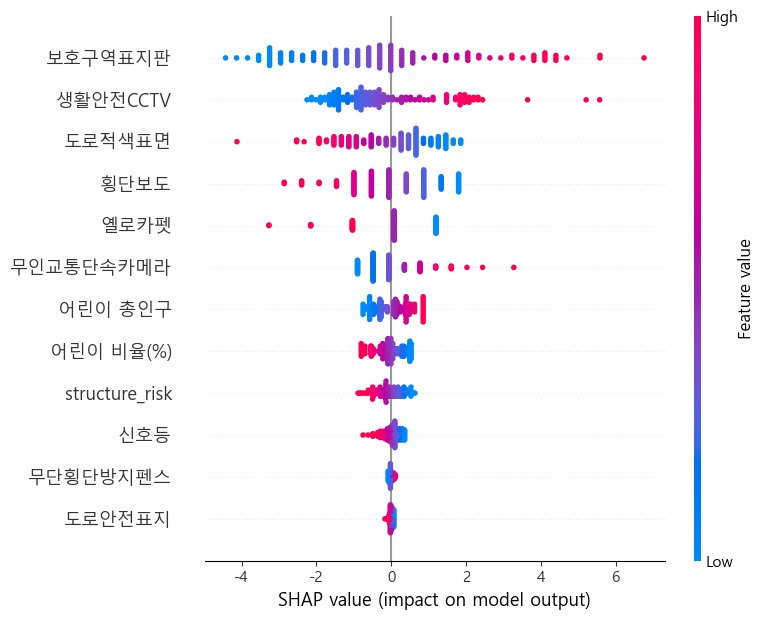


=== SHAP Feature Importance ===
           feature  shap_importance
5          보호구역표지판         1.850044
6         생활안전CCTV         1.188234
2           도로적색표면         0.950763
9             횡단보도         0.909069
8             옐로카펫         0.667104
4        무인교통단속카메라         0.569054
10         어린이 총인구         0.398941
11       어린이 비율(%)         0.287087
0   structure_risk         0.269057
7              신호등         0.179160
3         무단횡단방지펜스         0.041918
1           도로안전표지         0.034250

=== SHAP TOP5 Features ===
    feature  shap_importance
5   보호구역표지판         1.850044
6  생활안전CCTV         1.188234
2    도로적색표면         0.950763
9      횡단보도         0.909069
8      옐로카펫         0.667104


In [43]:
# ============================================================
# 정책 변수 중요도 분석
# Logistic 계수 기반 중요도 + SHAP 시각화
# ============================================================

# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'Malgun Gothic'   # 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False      # 마이너스 깨짐 방지

# ============================================================
# 1. Logistic 계수 기반 Feature Importance
# ============================================================

# 로지스틱 회귀 계수 추출
coef = model_2nd_lr.named_steps["logit"].coef_[0]

# 변수 중요도 데이터프레임 생성
importance = pd.DataFrame({
    "feature": features_2nd_lr,
    "coef": coef,
    "abs_coef": np.abs(coef)
})

# 절대값 기준 정렬
importance = importance.sort_values("abs_coef", ascending=False)

print("\n=== Logistic Coefficient Importance ===")
print(importance)


# ============================================================
# 2. Structure Risk 및 정책 변수 TOP5 확인
# ============================================================

top5 = importance.head(5)

print("\n=== TOP 5 Important Features ===")
print(top5[["feature", "coef"]])


# ============================================================
# 3. SHAP 기반 중요도 분석
# ============================================================

# Pipeline 내부 scaler 적용
X_scaled = model_2nd_lr.named_steps["scaler"].transform(X)

# 로지스틱 모델 추출
logit_model = model_2nd_lr.named_steps["logit"]

# SHAP explainer 생성
explainer = shap.LinearExplainer(
    logit_model,
    X_scaled
)

# SHAP 값 계산
shap_values = explainer.shap_values(X_scaled)


# ============================================================
# 6. SHAP Summary Plot (변수 중요도 시각화)
# ============================================================

print("\nGenerating SHAP Summary Plot...")

shap.summary_plot(
    shap_values,
    X,
    feature_names=features_2nd_lr,
)


# ============================================================
# 4. SHAP 평균 중요도 계산
# ============================================================

shap_importance = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "feature": features_2nd_lr,
    "shap_importance": shap_importance
}).sort_values("shap_importance", ascending=False)

print("\n=== SHAP Feature Importance ===")
print(shap_df)


# ============================================================
# 5. SHAP 중요도 TOP5 출력
# ============================================================

print("\n=== SHAP TOP5 Features ===")
print(shap_df.head(5))

정책 변수 중요도 분석 결과 해석

1. 분석 목적

스쿨존 사고 발생에 어떤 요소들이 **모델 판단에 가장 큰 영향을 주는지** 확인하기 위해  
두 가지 방법을 사용했다.

- **Logistic Regression 계수 분석**
- **SHAP 값 기반 중요도 분석**

두 방법의 결과가 **거의 동일하게 나타났다.**

---

2. 가장 영향이 큰 변수 (TOP 5)

| 순위 | 변수 | 의미 |
|---|---|---|
| 1 | 보호구역표지판 | 사고 위험 지역에서 많이 관측 |
| 2 | 생활안전CCTV | 위험 지역에서 설치된 경우 많음 |
| 3 | 도로적색표면 | 사고 감소와 관련 |
| 4 | 횡단보도 | 보행 안전 시설 |
| 5 | 옐로카펫 | 어린이 보호 시설 |

**해석**

- 안전시설이 **사고를 발생시키는 것이 아니라**
- **사고 위험이 높은 지역에 설치된 결과일 가능성**이 높다.

즉,

> 위험한 스쿨존일수록 안전시설이 많이 설치되어 있는 패턴이 나타난다.

---

3. 중간 영향 변수

| 변수 | 의미 |
|---|---|
| 무인교통단속카메라 | 차량 속도 관리 시설 |
| 어린이 총인구 | 어린이가 많을수록 사고 노출 증가 |
| 어린이 비율 | 지역 인구 구조 영향 |

어린이 인구가 많을수록 **사고 노출 가능성이 증가하는 경향**이 나타난다.

---

4. 영향이 상대적으로 작은 변수

| 변수 |
|---|
| structure_risk |
| 신호등 |
| 무단횡단방지펜스 |
| 도로안전표지 |

이 변수들은 모델에서 **상대적으로 영향력이 작은 변수**로 나타났다.

---

5. SHAP 그래프 해석

그래프에서

- **오른쪽 방향 → 사고 발생 확률 증가**
- **왼쪽 방향 → 사고 발생 확률 감소**

또한

- **빨간색 점 → 변수 값이 높은 경우**
- **파란색 점 → 변수 값이 낮은 경우**

즉,

- 특정 시설이 **존재하거나 값이 높을 때**
- 사고 확률이 **증가 또는 감소하는 방향**을 확인할 수 있다.

---

6. 종합 결론

모델 분석 결과

사고 위험과 가장 관련성이 높은 변수는 다음과 같다.

1. 보호구역표지판  
2. 생활안전CCTV  
3. 도로적색표면  
4. 횡단보도  
5. 옐로카펫  

이 결과는

- **사고 위험이 높은 지역일수록 안전시설이 집중 설치되는 경향**
- **보행 안전 시설은 사고 위험 감소와 연관**

이라는 패턴을 보여준다.

따라서

> 스쿨존 사고 예방 정책은  
> **위험 지역 선별 → 안전시설 집중 설치** 방식으로 활용할 수 있다.

##### 로지스틱 회귀 기반, 최종 안전점수 도출

In [44]:
# 사고 확률
facility_df["risk_prob"] = model_2nd_lr.predict_proba(X)[:,1]

# 위험 점수 (0~100)
facility_df["risk_score"] = facility_df["risk_prob"] * 100

# 안전 점수
facility_df["safety_score"] = 100 - facility_df["risk_score"]

# 안전 등급
facility_df["safety_grade"] = pd.qcut(
    facility_df["safety_score"],
    q=[0,0.25,0.5,0.75,1],
    labels=["D","C","B","A"]
)

# 파일로 저장
facility_df.to_csv(r"C:\Users\EL36\Desktop\1차프로젝트_CCTV\1stProject_MSAI09\ML_jw\3_final_scoring_results.csv", index=False)

#### 비교 모델 - ZINB 사고 발생 건수 예측 모델 (Zero-Inflated Negative Binomial)

In [45]:
# ============================================================
# 사고 발생 건수 예측 모델 (Zero-Inflated Negative Binomial)
# ============================================================

# 필요한 라이브러리 불러오기
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP
from sklearn.preprocessing import StandardScaler


# ============================================================
# 1. Feature 생성 및 전처리
# ============================================================

# 어린이 총인구는 분포가 매우 치우칠 수 있기 때문에
# 로그 변환(log1p)을 통해 스케일을 안정화
facility_df["log_children"] = np.log1p(facility_df["어린이 총인구"])

# 모델에 사용할 변수 정의
features_2nd_zinb = [
    "structure_risk",   # 이미지 기반 구조 위험 점수
    "신호등",           # 교통 신호등 존재 여부
    "횡단보도",         # 횡단보도 개수 또는 존재 여부
    "log_children"      # 로그 변환된 어린이 인구
]

# 입력 변수(X)와 타겟 변수(y) 정의
X = facility_df[features_2nd_zinb]
y = facility_df["발생건수"]   # 사고 발생 건수


# ============================================================
# 2. 데이터 스케일링 및 상수항 추가
# ============================================================

# StandardScaler를 이용하여 변수 스케일 정규화
X = StandardScaler().fit_transform(X)

# statsmodels 사용 시 상수항 추가 필요
X = sm.add_constant(X)


# ============================================================
# 3. Zero-Inflated Negative Binomial 모델 정의
# ============================================================

# ZINB 모델은
# 1) 사고가 전혀 발생하지 않는 구조 (Zero Inflation)
# 2) 사고 건수가 발생하는 구조 (Count Model)
# 를 동시에 모델링하는 방식

zinb_model = ZeroInflatedNegativeBinomialP(
    endog=y,        # 종속 변수 (사고 건수)
    exog=X,         # count model 설명 변수
    exog_infl=X,    # zero inflation 모델 설명 변수
    inflation="logit"  # zero inflation 부분을 로지스틱으로 모델링
)


# ============================================================
# 4. 모델 학습
# ============================================================

# 최대 반복 횟수 100으로 설정
result = zinb_model.fit(maxiter=100)

# 모델 요약 결과 출력
print(result.summary())


# ============================================================
# 5. 사고 발생 건수 예측
# ============================================================

# 각 스쿨존의 예상 사고 발생 건수 예측
facility_df["pred_accidents"] = result.predict(X)


# ============================================================
# 6. 정책 지표 계산 (Top-20% Capture)
# ============================================================

# 예측 사고 건수 기준 상위 20% 지역 선택
threshold = np.percentile(
    facility_df["pred_accidents"],
    80
)

top20 = facility_df[
    facility_df["pred_accidents"] >= threshold
]

# 상위 20% 위험지역이 전체 사고 중 얼마나 설명하는지 계산
capture = (
    top20["발생건수"].sum() /
    facility_df["발생건수"].sum()
)

print("Top20 Capture:", capture)

         Current function value: 0.330212
         Iterations: 100
         Function evaluations: 102
         Gradient evaluations: 102
                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                              발생건수   No. Observations:                  129
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                      124
Method:                                      MLE   Df Model:                            4
Date:                           Wed, 04 Mar 2026   Pseudo R-squ.:                -0.02619
Time:                                   21:57:57   Log-Likelihood:                -42.597
converged:                                 False   LL-Null:                       -41.510
Covariance Type:                       nonrobust   LLR p-value:                     1.000
                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

c:\Users\EL36\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\optimize\_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
c:\Users\EL36\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\EL36\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\EL36\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\discrete\discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
c:\Users\EL36\AppData\Local\Programs\Python\Python

사고 발생 건수 예측 모델 (ZINB) 결과 해석

1. 모델 학습 상태

| 항목 | 결과 |
|---|---|
| Iterations | 100 |
| Converged | False |
| Pseudo R² | -0.026 |

해석

- **Converged = False**

→ 모델이 **정상적으로 학습되지 않았다.**

- 반복 횟수 제한(100)에 도달했지만  
  **최적해를 찾지 못했다.**

- 따라서 **계수의 통계적 해석은 신뢰하기 어렵다.**

---

2. 통계 결과 문제

모델 결과에서 다음 문제가 발생했다.

| 문제 | 의미 |
|---|---|
| std err = nan | 표준오차 계산 실패 |
| z-value = nan | 통계 검정 불가 |
| p-value = nan | 변수 유의성 판단 불가 |
| Hessian inversion failed | 분산 계산 실패 |
| Maximum likelihood failed | 최적화 실패 |

원인 (추정)

다음 조건 중 하나 이상이 발생했을 가능성이 높다.

1. **데이터가 너무 적음**
2. **사고 건수가 대부분 0**
3. **변수 수 대비 표본 부족**
4. **Zero-inflation 구조 과적합**

현재 데이터

- 표본: **129**
- 사고 발생: **소수**

→ ZINB 모델에 **불안정한 조건**이다.

---

3. 정책 지표 (Top 20% Capture)

| 지표 | 값 |
|---|---|
| Top20 Capture | 0.625 |

의미

예측 사고 건수 기준

**위험 상위 20% 지역**

→ 전체 사고의 **62.5%를 포함**

즉

> 일부 사고 집중 지역은 식별하지만  
> 전체 사고를 충분히 설명하지는 못한다.

---

4. 현재 모델의 한계

현재 ZINB 모델은 다음 문제가 있다.

1. **모델 수렴 실패**
2. **통계적 해석 불가**
3. **정책 설명력 제한적**

따라서

> 현재 결과는 **참고 수준**으로만 사용할 수 있다.

---

5. 결론

현재 분석 결과

- ZINB 모델은 **정상적으로 수렴하지 않았다**
- 변수의 **통계적 유의성 해석은 불가능하다**
- 정책 성능도 **Top20 Capture = 62.5% 수준**이다.

따라서

> 본 연구에서는  
> **사고 발생 여부를 예측하는 Logistic 모델이 더 안정적인 성능을 보였다.**

#### NBR 사고 발생 건수 예측 모델 (Negative Binomial Regression)


In [46]:
# ============================================================
# 사고 발생 건수 예측 모델 (Negative Binomial Regression)
# ============================================================

# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler


# ============================================================
# 1. 데이터 준비
# ============================================================

# 어린이 총인구는 분포가 치우쳐 있을 가능성이 높기 때문에
# 로그 변환을 통해 스케일을 안정화 (log1p = log(1+x))
facility_df["log_children"] = np.log1p(facility_df["어린이 총인구"])

# 모델에 사용할 변수 정의
features_2nd_nb = [
    "structure_risk",   # 이미지 기반 구조 위험 점수
    "신호등",           # 교통 신호등 존재 여부
    "횡단보도",         # 횡단보도 존재 또는 개수
    "log_children"      # 로그 변환된 어린이 인구 (노출 변수)
]

# 입력 변수(X)와 타겟 변수(y) 정의
X = facility_df[features_2nd_nb]
y = facility_df["발생건수"]   # 사고 발생 건수


# ============================================================
# 2. Feature 스케일링
# ============================================================

# 변수 간 스케일 차이를 줄이기 위해 StandardScaler 사용
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# statsmodels는 intercept를 자동으로 추가하지 않기 때문에
# 상수항(constant)을 직접 추가
X_scaled = sm.add_constant(X_scaled)


# ============================================================
# 3. Negative Binomial 회귀 모델 학습
# ============================================================

# Negative Binomial 모델은
# 사고 건수처럼 분산이 큰 count 데이터에 적합한 모델

nb_model = sm.GLM(
    y,                      # 종속 변수 (사고 발생 건수)
    X_scaled,               # 설명 변수
    family=sm.families.NegativeBinomial()
)

# 모델 학습
result = nb_model.fit()

# 모델 요약 결과 출력
print(result.summary())


# ============================================================
# 4. 사고 발생 건수 예측
# ============================================================

# 각 스쿨존의 예상 사고 발생 건수 예측
facility_df["pred_accidents"] = result.predict(X_scaled)


# ============================================================
# 5. 정책 지표 계산 (Top 20% Capture)
# ============================================================

# 예측 사고 건수 기준 상위 20% 지역 선택
threshold = np.percentile(
    facility_df["pred_accidents"],
    80
)

top20 = facility_df[
    facility_df["pred_accidents"] >= threshold
]

# 상위 20% 위험지역이 전체 사고 중 얼마나 설명하는지 계산
capture_rate = (
    top20["발생건수"].sum() /
    facility_df["발생건수"].sum()
)

print("Top20 Capture:", capture_rate)


# ============================================================
# 6. Precision@20% (사고 밀도)
# ============================================================

# 상위 20% 위험지역에서 평균 사고 건수
# → 위험지역의 사고 집중도를 의미
precision20 = top20["발생건수"].mean()

print("Precision@20%:", precision20)


# ============================================================
# 7. 상위 위험 스쿨존 확인
# ============================================================

# 예측 사고 건수가 높은 순서대로 정렬
top_risk = facility_df.sort_values(
    "pred_accidents",
    ascending=False
).head(20)

# 상위 위험 지역 출력
print(top_risk[[
    "시설물명",
    "pred_accidents",
    "발생건수"
]])

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   발생건수   No. Observations:                  129
Model:                            GLM   Df Residuals:                      124
Model Family:        NegativeBinomial   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -63.888
Date:                Wed, 04 Mar 2026   Deviance:                       91.787
Time:                        21:57:57   Pearson chi2:                     296.
No. Iterations:                     6   Pseudo R-squ. (CS):            0.03920
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.8173      0.249     -7.304      0.0

c:\Users\EL36\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


사고 발생 건수 예측 모델 결과 해석 (Negative Binomial)

1. 모델 학습 상태

| 항목 | 값 |
|---|---|
| 표본 수 | 129 |
| 변수 수 | 4 |
| Pseudo R² | 0.039 |
| Iterations | 6 |

해석

- 모델은 **정상적으로 수렴(converged)** 했다.
- 그러나 **설명력(Pseudo R² = 0.039)** 이 매우 낮다.

즉

> 선택된 변수들이 사고 건수 변화를 충분히 설명하지 못한다.

---

2. 변수 영향 분석

| 변수 | 계수 | p-value | 해석 |
|---|---|---|---|
| structure_risk | -0.43 | 0.088 | 약한 음의 관계 |
| 신호등 | -0.15 | 0.617 | 통계적으로 의미 없음 |
| 횡단보도 | 0.11 | 0.694 | 통계적으로 의미 없음 |
| log_children | -0.22 | 0.302 | 통계적으로 의미 없음 |

해석

- **p-value < 0.05인 변수 없음**
- 즉 **통계적으로 유의한 변수는 발견되지 않았다.**

가능한 이유

- 사고 건수가 대부분 **0 또는 1**
- 데이터 수 **129개로 매우 제한적**
- 시설 변수의 **변동성이 낮음**

---

3. 정책 성능 평가

Top 20% Capture

| 지표 | 값 |
|---|---|
| Top20 Capture | 0.25 |

**의미**

- 위험 상위 20% 지역이  
- 전체 사고의 **25%만 설명**

즉

> 위험 지역 선별 능력이 낮다.

---

Precision@20%

| 지표 | 값 |
|---|---|
| Precision@20% | 0.23 |

**의미**

- 위험 상위 지역의 평균 사고 건수  
- **약 0.23건 수준**

즉

> 사고가 집중되는 패턴을 잘 잡지 못한다.

---

4. 상위 위험 지역 결과 특징

상위 예측 지역 중

- **실제 사고 0건 지역이 다수 포함**

예시

| 시설 | 예측 사고 | 실제 사고 |
|---|---|---|
| 성남수정초 | 0.50 | 0 |
| 성남장안초 | 0.49 | 0 |
| 성남북초 | 0.47 | 0 |

즉

> 모델이 **실제 사고 분포를 잘 설명하지 못한다.**

---

5. 전체 결론

Negative Binomial 모델 결과

1. 모델은 **수렴은 했지만 설명력이 매우 낮다**
2. **통계적으로 유의한 변수 없음**
3. **위험 지역 선별 성능도 낮음**

따라서

> 사고 건수 예측에는 **현재 변수 구조가 충분하지 않다.**

현재 데이터 구조에서는

**사고 발생 여부를 예측하는 Logistic 모델이 더 안정적이고 실용적인 성능을 보인다.**